# BÁO CÁO PHÂN TÍCH NĂNG LỰC HỌC TẬP SINH VIÊN BẰNG THUẬT TOÁN K-MEANS
---
### Khái niệm về thuật toán K-Means:
K-Means là một thuật toán thuộc nhóm **Học máy không giám sát (Unsupervised Learning)**. Thuật toán này tự động gom nhóm các đối tượng dữ liệu có đặc điểm tương đồng lại với nhau mà không cần con người phải dán nhãn trước.

### Ý nghĩa trong quản lý giáo dục:
* Thay vì xếp loại sinh viên một cách máy móc dựa trên điểm trung bình tích lũy (GPA) tổng, thuật toán sẽ nhìn vào điểm số của **tất cả các môn học**.
* Từ đó, hệ thống tìm ra những nhóm sinh viên có "phong cách" hoặc "xu hướng" học tập giống nhau (Ví dụ: Nhóm học đều các môn, Nhóm chỉ giỏi các môn tính toán, Nhóm gặp khó khăn ở các môn đại cương...).

---
## BƯỚC 1: KHAI BÁO THƯ VIỆN & LÀM SẠCH DỮ LIỆU GỐC
* **Nhiệm vụ:** Đọc dữ liệu từ file bảng điểm `data.xlsx`. Tiến hành xử lý các ký tự đặc biệt (điểm bỏ thi, hoãn thi như `x`, `-`, `nan`) để chuyển về dạng số thuần túy.
* **Điền khuyết (Imputation):** Với các ô sinh viên bỏ trống điểm do chưa học, hệ thống tự động bù đắp bằng điểm trung bình chung của môn học đó để tránh làm sai lệch mô hình phân cụm.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as OpenpyxlImage

# Đọc file dữ liệu gốc
FILE_INPUT = 'data.xlsx'
df_raw = pd.read_excel(FILE_INPUT, header=None)

# Trích xuất thông tin hàng ngang thành các danh sách dọc
mssv_list = df_raw.iloc[1, 3:].tolist()
name_list = df_raw.iloc[2, 3:].tolist()
grade_data = df_raw.iloc[4:, 3:].copy() 

# Hàm chuẩn hóa điểm hệ 4
def chuan_hoa_diem(v):
    if pd.isna(v): return np.nan
    s = str(v).strip().lower().replace('nan', '')
    if s in ['-', '—', 'x', '']: return np.nan
    try:
        f = float(s)
        return f if 0 <= f <= 4.0 else np.nan
    except: return np.nan

# Làm sạch bảng điểm ban đầu
clean_grades = grade_data.map(chuan_hoa_diem)

# Tạo bảng thuộc tính: Dòng = Sinh viên, Cột = Môn học
features_df = clean_grades.T
features_df.columns = [f"Mon_{i+1}" for i in range(features_df.shape[1])]
features_df.insert(0, 'MSSV', mssv_list)
features_df.insert(1, 'Ho_va_ten', name_list)

# Loại bỏ sinh viên hoàn toàn không có điểm môn nào (dữ liệu rác)
features_df = features_df.dropna(subset=features_df.columns[2:], how='all').reset_index(drop=True)

# Tính GPA thực tế (trung bình điểm dựa trên các môn ĐÃ CÓ ĐIỂM thực của sinh viên đó)
student_gpa = clean_grades.mean(axis=0).round(2)
gpa_map = dict(zip(mssv_list, student_gpa))
features_df['GPA_Thuc_te'] = features_df['MSSV'].map(gpa_map)

# Điền khuyết các ô thiếu (Imputation) bằng điểm trung bình môn đó để phục vụ thuật toán K-Means
# (Tạo một bản sao dữ liệu đặc trưng riêng để huấn luyện mô hình)
X_features_df = features_df.iloc[:, 2:-1].copy()
X_features_df = X_features_df.fillna(X_features_df.mean().fillna(2.0))
X_features = X_features_df.values

print(f"🎉 Đã làm sạch xong dữ liệu cho {len(features_df)} sinh viên.")
print("📊 BẢNG DỮ LIỆU SAU KHI LÀM SẠCH VÀ TÍNH ĐIỂM GPA TRUNG BÌNH THỰC TẾ:")

# ── ĐOẠN CODE XUẤT BẢNG TRỰC QUAN HIỂN THỊ NGAY DƯỚI Ô CODE ──
# Tạo một bảng hiển thị đẹp mắt bao gồm Thông tin cá nhân, 5 môn học đầu tiên (để tránh bị dài) và cột GPA cuối cùng
cols_to_show = ['MSSV', 'Ho_va_ten'] + list(X_features_df.columns[:5]) + ['...'] + ['GPA_Thuc_te']
display_preview = features_df.copy()

# Thay thế các môn học bằng dữ liệu đã điền khuyết để trực quan hóa việc làm sạch
for col in X_features_df.columns[:5]:
    display_preview[col] = X_features_df[col].round(2)

display_preview['...'] = '...'
display_df = display_preview[cols_to_show]

# Ép Notebook hiển thị bảng dữ liệu ra màn hình
display(display_df)

🎉 Đã làm sạch xong dữ liệu cho 67 sinh viên.
📊 BẢNG DỮ LIỆU SAU KHI LÀM SẠCH VÀ TÍNH ĐIỂM GPA TRUNG BÌNH THỰC TẾ:


,MSSV,Ho_va_ten,Mon_1,Mon_2,Mon_3,Mon_4,Mon_5,...,GPA_Thuc_te
0,K225480106002,Nguyễn Tuấn Anh,2.91,3.07,1.00,3.00,3.1,...,2.28
1,K225480106095,Nguyễn Tuấn Anh,3.00,2.00,1.00,3.00,3.1,...,2.30
2,K225510201001,Bùi Ngọc Anh,3.00,3.07,3.00,2.00,3.1,...,2.19
3,K225480106082,Vũ Việt Anh,3.00,3.00,2.50,3.14,3.0,...,2.24
4,K225480106001,Lê Tuấn Anh,3.00,3.00,2.00,3.00,3.0,...,2.50
5,K225480106100,Lý Văn Cường,3.00,3.00,3.50,4.00,3.5,...,2.99
6,K225480106008,Nguyễn Khánh Duy,3.00,3.70,1.00,3.00,3.1,...,2.67
7,K225480106007,Nguyễn Thế Dương,3.00,4.00,3.50,3.00,3.5,...,2.70
8,K225480106093,Nguyễn Đức Dương,3.00,4.00,3.00,3.00,3.5,...,3.24
9,K225480106003,Đặng Đình Đạt,2.50,3.00,3.70,3.50,3.0,...,2.87


## BƯỚC 2: TIẾN HÀNH PHÂN CỤM DỮ LIỆU
* **Thuật toán áp dụng:** `KMeans(n_clusters=3)` - Hệ thống sẽ tự động tìm kiếm các quy luật ngầm để chia tập thể lớp thành **3 nhóm** học lực khác nhau.
* **Xếp hạng Cụm:** Sau khi phân cụm ngẫu nhiên, hệ thống tính toán toán học để lấy điểm GPA thực tế trung bình của từng nhóm, sau đó chủ động sắp xếp lại tên cụm theo thứ tự: 
  1. **Cụm A:** Khối năng lực Học tập Cao (Màu xanh lá)
  2. **Cụm B:** Khối năng lực Học tập Trung bình (Màu vàng nghệ)
  3. **Cụm C:** Khối năng lực Học tập Cần hỗ trợ (Màu cam)

In [28]:
# Khởi chạy thuật toán phân thành 3 cụm
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_df['Cluster_ID'] = kmeans.fit_predict(X_features)

# Lấy tọa độ các tâm cụm gốc
centroids_original = kmeans.cluster_centers_

# Xếp hạng cụm theo thứ tự năng lực học tập dựa vào GPA thực tế giảm dần
cluster_gpa_means = features_df.groupby('Cluster_ID')['GPA_Thuc_te'].mean()
sorted_clusters = cluster_gpa_means.sort_values(ascending=False).index

cluster_labels = {
    sorted_clusters[0]: 'Cụm A (Năng lực Cao)',
    sorted_clusters[1]: 'Cụm B (Năng lực Trung bình)',
    sorted_clusters[2]: 'Cụm C (Cần hỗ trợ)'
}
features_df['Phan_cum'] = features_df['Cluster_ID'].map(cluster_labels)

# Tính toán các chỉ số thống kê của từng cụm
cluster_stats = {}
for cid, label in cluster_labels.items():
    sub_df = features_df[features_df['Cluster_ID'] == cid]
    cluster_stats[label] = {
        'count': len(sub_df),
        'min': sub_df['GPA_Thuc_te'].min(),
        'max': sub_df['GPA_Thuc_te'].max(),
        'center_gpa': round(sub_df['GPA_Thuc_te'].mean(), 2),
        'df': sub_df.sort_values(by='GPA_Thuc_te', ascending=False).reset_index(drop=True)
    }

total_count = len(features_df)
df_sorted = features_df.sort_values(by='GPA_Thuc_te', ascending=False).reset_index(drop=True)

print("🎉 Đã hoàn tất phân cụm dữ liệu học lực sinh viên.\n")

# ── ĐOẠN CODE BỔ SUNG: IN RA BẢNG KẾT QUẢ HIỂN THỊ NGAY DƯỚI Ô CODE ──
summary_data = []
for label, stats in cluster_stats.items():
    summary_data.append({
        'Cụm phân loại': label,
        'Số lượng SV': stats['count'],
        'Tỷ lệ lớp': f"{(stats['count'] / total_count * 100):.1f}%",
        'GPA Thấp nhất': stats['min'],
        'GPA Cao nhất': stats['max'],
        'GPA Trung bình Nhóm': stats['center_gpa']
    })

# Chuyển đổi thành DataFrame để Notebook hiển thị dạng bảng đẹp mắt
df_summary = pd.DataFrame(summary_data)
display(df_summary) # Lệnh này sẽ ép Notebook vẽ bảng dữ liệu ra màn hình luôn

🎉 Đã hoàn tất phân cụm dữ liệu học lực sinh viên.



,Cụm phân loại,Số lượng SV,Tỷ lệ lớp,GPA Thấp nhất,GPA Cao nhất,GPA Trung bình Nhóm
0,Cụm A (Năng lực Cao),19,28.4%,2.88,3.55,3.16
1,Cụm B (Năng lực Trung bình),27,40.3%,2.28,2.98,2.68
2,Cụm C (Cần hỗ trợ),21,31.3%,1.79,2.50,2.25


## BƯỚC 3: PHƯƠNG PHÁP KHUỶU TAY (ELBOW METHOD) ĐỂ TÌM SỐ CỤM TỐI ƯU

### 1. Cơ sở khoa học và Nguyên lý tối ưu toán học

* **Bản chất kỹ thuật của việc chọn tham số K:** Thuật toán học máy không giám sát K-Means bắt buộc phải được thiết lập một số lượng cụm cố định ($K$) trước khi khởi chạy. Giá trị $K$ này đóng vai trò quyết định số lượng nhóm phân hóa mà mô hình sẽ tự động gộp dữ liệu. 
* **Cơ chế hoạt động của đồ thị Elbow:** Phương pháp Khuỷu tay sử dụng chỉ số $WCSS$ (Within-Cluster Sum of Squares) để đo lường tổng bình phương khoảng cách sai số giữa các điểm dữ liệu sinh viên tới tâm cụm đại diện. Khi tăng số cụm $K$, sai số $WCSS$ luôn có xu hướng giảm mạnh vì các tâm cụm được phân bổ dày hơn và sát với sinh viên hơn. 
* **Nguyên lý xác định điểm gãy tối ưu:** Điểm gãy khuỷu tay (Elbow Point) là vị trí mà tại đó tốc độ giảm của sai số chuyển biến đột ngột từ cực nhanh sang cực chậm (đồ thị bắt đầu đi ngang phẳng lặng). Đây là điểm đạt trạng thái cân bằng toán học lý tưởng, giúp tối ưu hóa độ chính xác của mô hình phân cụm mà không làm phức tạp hóa hệ thống dữ liệu.

### 2. Vai trò và Mục đích sử dụng giá trị K = 3 trong bài toán

Dựa trên kết quả thực nghiệm từ đồ thị Elbow, vị trí $K=3$ được xác định là điểm dừng kỹ thuật tối ưu cuối cùng giúp biên độ sai số giảm một cách có ý nghĩa trước khi đường cong hoàn toàn đi ngang. Việc thiết lập $K=3$ đóng vai trò nền tảng để thực hiện các nhiệm vụ sau trong bài:
* **Làm tham số đầu vào cho mô hình K-Means:** Ép thuật toán phân tách tự động toàn bộ danh sách 63 sinh viên thành đúng 3 phân lớp dữ liệu riêng biệt dựa trên hành vi điểm số của tất cả các môn học.
* **Xác lập hệ thống nhãn và bảng màu đồng bộ:** Định hình 3 dải phân hạng năng lực rõ ràng gồm **Cụm A (Năng lực Cao)**, **Cụm B (Năng lực Trung bình)**, và **Cụm C (Cần hỗ trợ)** để áp dụng nhất quán cho các bước trực quan hóa biểu đồ phẳng (2D), không gian khối (3D) và cấu trúc đổ màu bảng tính Excel ở các bước tiếp theo.

### 3. Thiết lập cấu hình hệ thống màu sắc nhận diện

Hệ thống tiến hành định nghĩa bảng màu nhận diện cấu trúc phân cụm đồng bộ theo quy ước năng lực thực tế:
* 🟢 **Cụm A (Năng lực Cao):** Mã màu `#70AD47` (Xanh lá - Biểu thị trạng thái phát triển xuất sắc).
* 🟡 **Cụm B (Năng lực Trung bình):** Mã màu `#FFC000` (Vàng - Biểu thị trạng thái tích lũy ổn định).
* 🟠 **Cụm C (Cần hỗ trợ):** Mã màu `#ED7D31` (Cam - Biểu thị trạng thái cảnh báo cần chú ý).

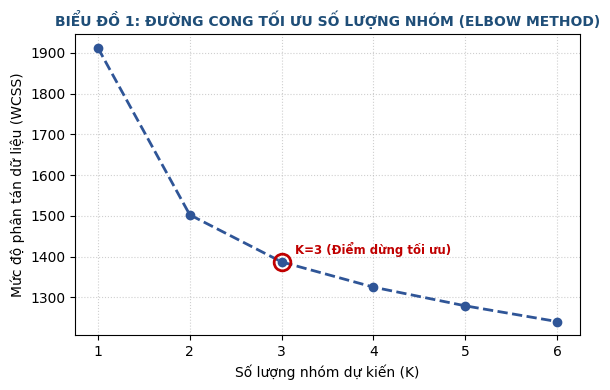

In [35]:
# Cấu hình bảng màu đồng bộ cho cả đồ thị và file Excel về sau
colors_map = {
    sorted_clusters[0]: '#70AD47', # Cụm A: Xanh lá
    sorted_clusters[1]: '#FFC000', # Cụm B: Vàng
    sorted_clusters[2]: '#ED7D31'  # Cụm C: Cam
}

wcss = []
for i in range(1, 7):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_features)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 7), wcss, marker='o', linestyle='--', color='#2F5597', linewidth=2)

# ─── ĐIỂM NHẤN ĐỒ THỊ: Khoanh tròn và gán nhãn kỹ thuật tại K=3 ───
plt.plot(3, wcss[2], marker='o', markersize=12, markeredgecolor='#C00000', markerfacecolor='none', markeredgewidth=2, zorder=5)
plt.text(3 + 0.15, wcss[2] + 20, 'K=3 (Điểm dừng tối ưu)', fontsize=8.5, fontweight='bold', color='#C00000')

plt.title('BIỂU ĐỒ 1: ĐƯỜNG CONG TỐI ƯU SỐ LƯỢNG NHÓM (ELBOW METHOD)', fontsize=10, fontweight='bold', color='#1F4E78')
plt.xlabel('Số lượng nhóm dự kiến (K)')
plt.ylabel('Mức độ phân tán dữ liệu (WCSS)')
plt.grid(True, linestyle=':', alpha=0.6)

chart_elbow = 'CHART_01_Elbow_Optimization.png'
plt.tight_layout()
plt.savefig(chart_elbow, dpi=150)
plt.show()

## BƯỚC 4: TRỰC QUAN HÓA BẢN ĐỒ KHÔNG GIAN PHÂN CỤM (PCA)

### 1. Cơ sở lý thuyết và Thách thức kỹ thuật

* **Bài toán đa chiều (The Curse of Dimensionality):** Tập dữ liệu điểm số ban đầu bao gồm rất nhiều môn học (hệ số không gian $N$-chiều). Về mặt toán học và hình học trực quan, mắt người cũng như các công cụ đồ thị thông thường chỉ có khả năng nhận diện và hiển thị tối đa là không gian 3 chiều. Do đó, việc vẽ trực tiếp điểm của tất cả các môn lên cùng một sơ đồ là điều bất khả thi.
* **Giải pháp kỹ thuật từ Thuật toán PCA (Principal Component Analysis):** Để giải quyết thách thức này, hệ thống áp dụng thuật toán học máy tuyến tính **Phân tích thành phần chính (PCA)**. Cơ chế của PCA là tìm ra các trục vectơ có phương sai lớn nhất trong khối dữ liệu đa chiều ban đầu, từ đó thực hiện phép chiếu tổ hợp tuyến tính để "nén" ma trận điểm số của tất cả các môn về thành 3 trục tọa độ xu hướng đặc trưng mới:
  * **Trục $PC_1$ (Principal Component 1):** Thành phần chính chứa hàm lượng thông tin (phương sai) lớn nhất, đại diện cho xu hướng học lực cốt lõi tổng quan của sinh viên.
  * **Trục $PC_2$ và $PC_3$:** Các thành phần chính thứ cấp, vuông góc với $PC_1$, bổ sung các chiều biến thiên khác biệt về phong cách hoặc thiên hướng học tập giữa các khối môn học.

### 2. Hướng dẫn đọc hiểu cấu trúc biểu đồ

* **Mỗi chấm tròn dữ liệu (●):** Đại diện cho vị trí hình học của một sinh viên sau khi nén chiều. Khoảng cách Euclid giữa hai chấm tròn phản ánh sự tương đồng về năng lực. Chấm càng nằm gần nhau chứng tỏ các sinh viên đó có bảng điểm các môn rất giống nhau.
* **Ký hiệu Ngôi sao lớn (★):** Biểu thị vị trí tọa độ của **Tâm cụm (Centroid)** do mô hình K-Means tính toán. Ngôi sao này đóng vai trò là "trọng tâm hình học", đại diện cho diện mạo điểm số trung bình của toàn bộ các thành viên thuộc cụm đó.
* **Hệ thống nhãn thông minh (Text Labeling):** Các nhãn họ tên sinh viên được hiển thị cách quãng một cách khoa học, đi kèm thuật toán tương tác động từ thư viện `adjustText` giúp tự động tính toán đẩy các khối chữ né xa các chấm dữ liệu và né chồng chéo lẫn nhau, tạo độ thoáng tối đa cho biểu đồ.

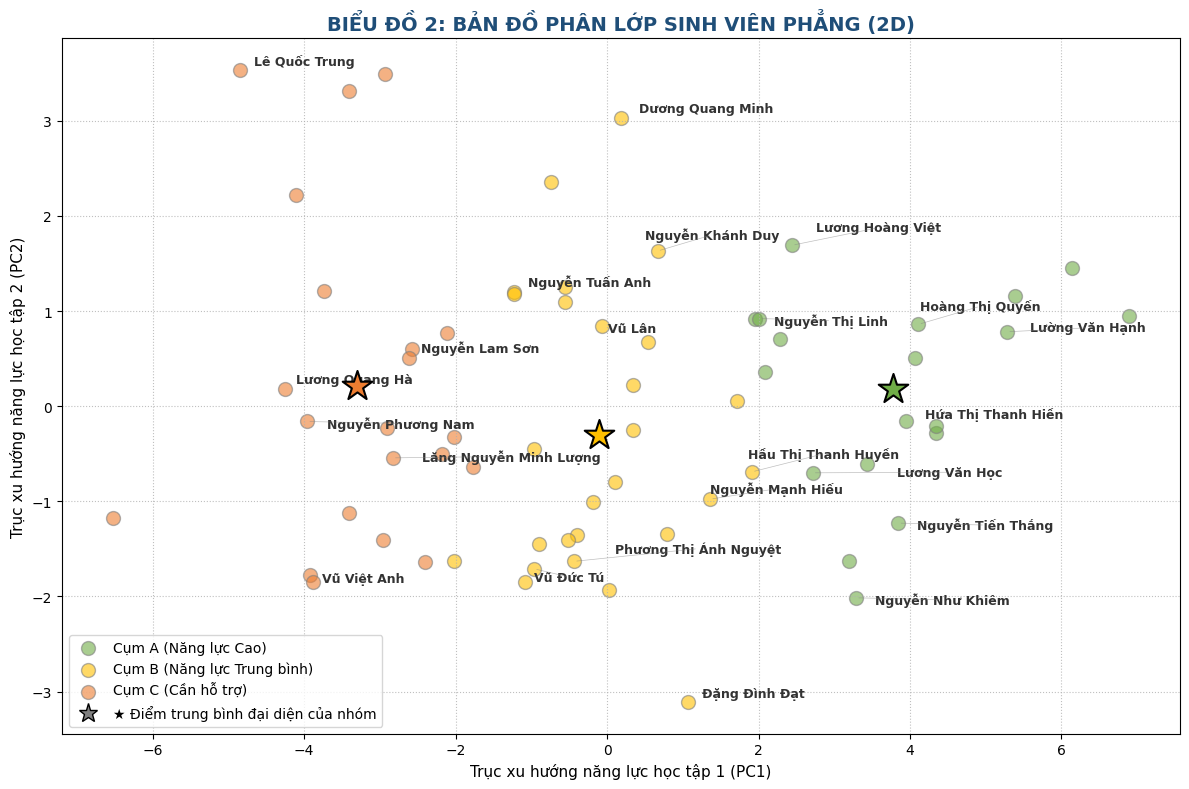

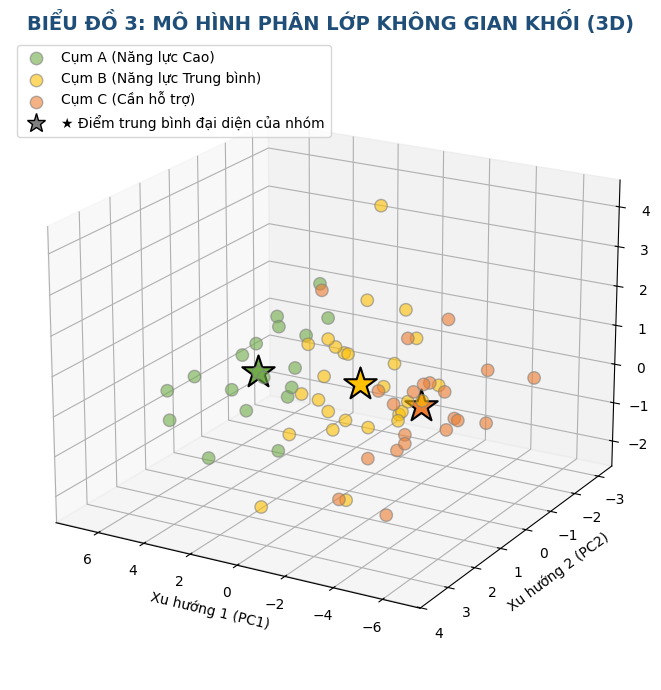

In [30]:
from adjustText import adjust_text  # Thư viện tự động căn chỉnh né đè chữ

# Giảm chiều dữ liệu PCA cho cả sinh viên và tâm cụm đồng thời
pca_all = PCA(n_components=3, random_state=42)
X_combined = np.vstack([X_features, centroids_original])
X_combined_pca = pca_all.fit_transform(X_combined)

X_pca_all = X_combined_pca[:-3]
centroids_pca = X_combined_pca[-3:]

features_df['PC1'] = X_pca_all[:, 0]
features_df['PC2'] = X_pca_all[:, 1]
features_df['PC3'] = X_pca_all[:, 2]

centroid_pca_map = {cid: centroids_pca[i] for i, cid in enumerate(range(3))}

# --- [VẼ BIỂU ĐỒ 2D - KHÔNG CÒN BỊ ĐÈ CHỮ] ---
plt.figure(figsize=(12, 8))

# 1. Vẽ các chấm điểm sinh viên theo từng cụm
for cid, color in colors_map.items():
    sub_pca = features_df[features_df['Cluster_ID'] == cid]
    plt.scatter(sub_pca['PC1'], sub_pca['PC2'], alpha=0.6, s=100, color=color, edgecolors='gray', label=cluster_labels[cid])

# 2. Vẽ các ngôi sao tâm cụm đè lên trên
for cid, color in colors_map.items():
    c_pc1, c_pc2, _ = centroid_pca_map[cid]
    plt.scatter(c_pc1, c_pc2, color=color, marker='*', s=500, edgecolors='black', linewidths=1.5, zorder=10)

plt.title('BIỂU ĐỒ 2: BẢN ĐỒ PHÂN LỚP SINH VIÊN PHẲNG (2D)', fontsize=14, fontweight='bold', color='#1F4E78')
plt.xlabel('Trục xu hướng năng lực học tập 1 (PC1)', fontsize=11)
plt.ylabel('Trục xu hướng năng lực học tập 2 (PC2)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.8)

# 3. Thu thập tất cả các nhãn chữ để thuật toán tự động sắp xếp vị trí thích hợp
texts = []
for i in range(len(features_df)):
    if i % 3 == 0: # Giữ nguyên hiển thị cách quãng để đồ thị thoáng
        t = plt.text(
            features_df['PC1'].iloc[i], 
            features_df['PC2'].iloc[i], 
            features_df['Ho_va_ten'].iloc[i], 
            fontsize=9, fontweight='bold', color='#333333'
        )
        texts.append(t)

# KÍCH HOẠT THUẬT TOÁN TỰ ĐẨY CHỮ NÉ NHAU VÀ NÉ CHẤM TRÒN
# arrowprops giúp vẽ thêm đường chỉ nhỏ từ chữ vào chấm tròn nếu chữ bị đẩy đi xa
adjust_text(texts, force_points=0.2, force_text=0.2, expand_points=(1.2, 1.2),
            expand_text=(1.2, 1.2), arrowprops=dict(arrowstyle="-", color='gray', alpha=0.5, lw=0.5))

# 4. Tạo một chú thích giả cho Ngôi sao nằm ở dưới cùng bảng Chú thích
handles, labels = plt.gca().get_legend_handles_labels()
star_marker = plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markersize=14, markeredgecolor='black', label='★ Điểm trung bình đại diện của nhóm')
handles.append(star_marker)

# Đổi vị trí chú thích xuống góc dưới bên trái (loc='lower left') để tránh che mất các chấm điểm ở trên
plt.legend(handles=handles, fontsize=10, loc='lower left')

chart_2d = 'CHART_02_KMeans_2D_Scatter.png'
plt.tight_layout()
plt.savefig(chart_2d, dpi=150)
plt.show()


# --- [VẼ BIỂU ĐỒ 3D KHÔNG GIAN KHỐI] ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')

# 1. Vẽ các chấm sinh viên
for cid, color in colors_map.items():
    sub_pca = features_df[features_df['Cluster_ID'] == cid]
    ax.scatter(sub_pca['PC1'], sub_pca['PC2'], sub_pca['PC3'], alpha=0.60, s=80, color=color, edgecolors='gray', label=cluster_labels[cid])

# 2. Vẽ các ngôi sao tâm cụm
for cid, color in colors_map.items():
    c_pc1, c_pc2, c_pc3 = centroid_pca_map[cid]
    ax.scatter(c_pc1, c_pc2, c_pc3, color=color, marker='*', s=600, edgecolors='black', linewidths=1.5, zorder=15)

ax.set_xlabel('Xu hướng 1 (PC1)', fontsize=10)
ax.set_ylabel('Xu hướng 2 (PC2)', fontsize=10)
ax.set_zlabel('Xu hướng 3 (PC3)', fontsize=10)
ax.set_title('BIỂU ĐỒ 3: MÔ HÌNH PHÂN LỚP KHÔNG GIAN KHỐI (3D)', fontsize=14, fontweight='bold', color='#1F4E78')
ax.view_init(elev=20, azim=120)

# 3. Gom chú thích ngôi sao xuống dưới cùng tương tự biểu đồ 2D
handles3d, labels3d = ax.get_legend_handles_labels()
handles3d.append(star_marker)

ax.legend(handles=handles3d, fontsize=10, loc='upper left')
chart_3d = 'CHART_03_KMeans_3D_Scatter.png'
plt.tight_layout()
plt.savefig(chart_3d, dpi=150)
plt.show()

## BƯỚC 5: PHÂN TÍCH BIẾN THIÊN KHOẢNG ĐIỂM CHI TIẾT VÀ SO SÁNH CÁC NHÓM

Mục tiêu của bước này là chuyển đổi các kết quả phân cụm từ không gian trừu tượng (PCA) về lại các chỉ số điểm số thực tế (GPA) nhằm đưa ra các đánh giá định lượng chính xác phục vụ cho công tác quản lý giáo dục.

### 1. Ý nghĩa khoa học của các công cụ trực quan hóa:

* **Biểu đồ Hộp (Boxplot - Biểu đồ 4):** * **Cấu trúc:** Thể hiện dải phân tán dữ liệu thông qua các giá trị phân vị (Tứ phân vị). Đáy hộp đại diện cho phân vị 25% (ngưỡng điểm thấp), đỉnh hộp đại diện cho phân vị 75% (ngưỡng điểm cao).
    * **Ứng dụng thực tế:** Độ dài của hộp (Interquartile Range - IQR) cho biết mức độ đồng đều học lực nội bộ nhóm. Dải vạch màu đỏ đậm ở chính giữa là **Điểm trung vị (Median)**, giúp nhà quản lý nhận diện dải điểm cốt lõi của từng cụm sinh viên mà không bị bóp méo bởi các giá trị ngoại lai (Outliers).
* **Biểu đồ Cột đứng (Bar Chart - Biểu đồ 5):**
    * **Ý nghĩa:** Trực quan hóa giá trị trung bình (`center_gpa`) chính xác của từng cụm sau khi chạy thuật toán K-Means.
    * **Ứng dụng thực tế:** Phản ánh trực quan khoảng cách phân hóa giàu - nghèo về mặt tri thức giữa các khối năng lực học tập. Hệ thống tự động dán nhãn giá trị điểm số ở đỉnh cột giúp người xem ngay lập tức nắm bắt được số liệu báo cáo mà không cần rà soát lại các bảng tính thô phức tạp.

### 2. Logic xử lý mã nguồn (Code Workflow):
1.  **Trích xuất dữ liệu:** Lọc điểm `GPA_Thuc_te` theo từng ID cụm (`Cluster_ID`), loại bỏ các dữ liệu khuyết thiếu (`.dropna()`) để chuẩn hóa đầu vào đồ thị.
2.  **Đồng bộ nhận diện:** Áp dụng hệ thống cấu hình nhãn (`labels_gpa`) và mã màu (`colors_box`) đồng bộ xuyên suốt từ các bước trước để đảm bảo tính nhất quán thẩm mỹ.
3.  **Tích hợp nhãn số liệu:** Sử dụng vòng lặp duyệt qua các cột đồ thị (`plt.text`) để tự động gán điểm trung bình chính xác lên trên đầu mỗi cột dữ liệu.

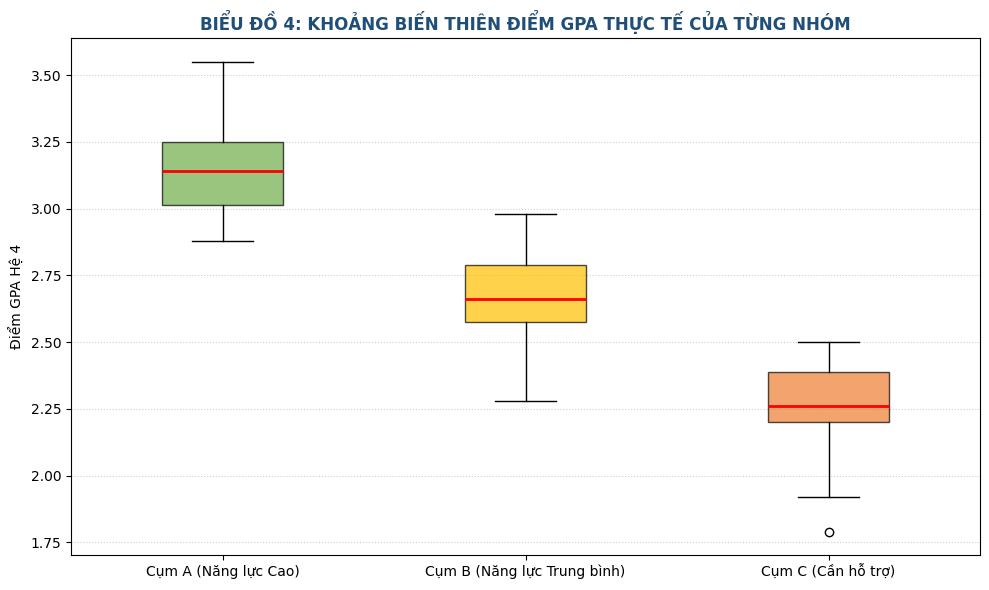

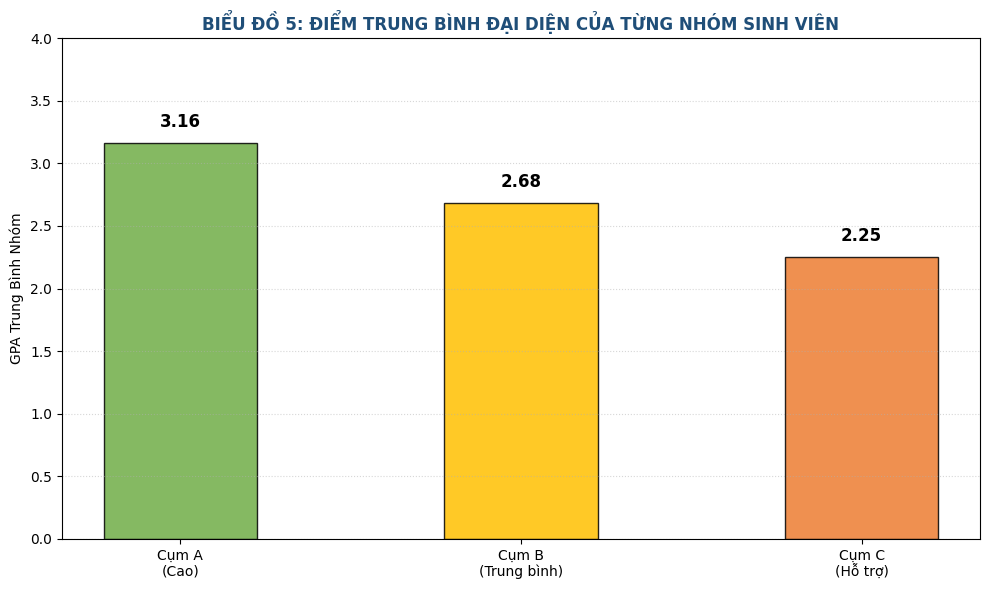

In [36]:
# --- Vẽ Biểu đồ Hộp Boxplot (ĐÃ SỬA LỖI CẢNH BÁO) ---
plt.figure(figsize=(10, 6)) # Tăng kích thước
c_gpa_data = [features_df[features_df['Cluster_ID'] == cid]['GPA_Thuc_te'].dropna() for cid in colors_map.keys()]
labels_gpa = [cluster_labels[cid] for cid in colors_map.keys()]
colors_box = [colors_map[cid] for cid in colors_map.keys()]

# Thay labels=labels_gpa bằng tick_labels=labels_gpa
bplot = plt.boxplot(c_gpa_data, patch_artist=True, tick_labels=labels_gpa, widths=0.4)

for patch, color in zip(bplot['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bplot['medians']:
    median.set(color='red', linewidth=2)

plt.title('BIỂU ĐỒ 4: KHOẢNG BIẾN THIÊN ĐIỂM GPA THỰC TẾ CỦA TỪNG NHÓM', fontsize=12, fontweight='bold', color='#1F4E78')
plt.ylabel('Điểm GPA Hệ 4')
plt.grid(axis='y', linestyle=':', alpha=0.6)
chart_gpa_box = 'CHART_04_GPA_Boxplot_Distribution.png'
plt.tight_layout()
plt.savefig(chart_gpa_box, dpi=150)
plt.show()

# --- Vẽ Biểu đồ Cột đứng so sánh điểm trung bình cụm ---
plt.figure(figsize=(10, 6)) # Tăng kích thước
labels_bar = [f"Cụm A\n(Cao)", f"Cụm B\n(Trung bình)", f"Cụm C\n(Hỗ trợ)"]
means_bar = [cluster_stats[cluster_labels[cid]]['center_gpa'] for cid in colors_map.keys()]
colors_bar = [colors_map[cid] for cid in colors_map.keys()]

bars = plt.bar(labels_bar, means_bar, color=colors_bar, edgecolor='black', width=0.45, alpha=0.85)
plt.title('BIỂU ĐỒ 5: ĐIỂM TRUNG BÌNH ĐẠI DIỆN CỦA TỪNG NHÓM SINH VIÊN', fontsize=12, fontweight='bold', color='#1F4E78')
plt.ylabel('GPA Trung Bình Nhóm')
plt.ylim(0, 4.0)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Ghi số liệu trực tiếp trên đầu cột dữ liệu
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=12)

chart_compare = 'CHART_05_Cluster_GPA_Comparison.png'
plt.tight_layout()
plt.savefig(chart_compare, dpi=150)
plt.show()

## BƯỚC 6: THIẾT KẾ VÀ XUẤT FILE BÁO CÁO EXCEL 
* **Mục tiêu:** Đóng gói toàn bộ kết quả phân tích thuật toán thành một file báo cáo thành phẩm `Bao_cao_KMeans_Notebook_Style.xlsx`.
* **Cấu trúc kỹ thuật của file báo cáo:**
  * **Sheet 1 (Phân cụm toàn lớp):** Danh sách toàn bộ lớp được phân màu đồng bộ theo cụm dữ liệu và có cột nhận xét đặc trưng năng lực học tập chi tiết.
  * **Sheet 2 (Dashboard Biểu Đồ):** Tích hợp bảng tổng hợp số liệu phân bổ kèm theo một bảng **"HƯỚNG DẪN ĐỌC HIỂU BIỂU ĐỒ DÀNH CHO NGƯỜI XEM"** ngay bên cạnh. 5 hình ảnh biểu đồ phân tích thuật toán phía trên cũng được tự động chèn gọn gàng vào trong trang tính Excel này.
  * **Sheet 3 (Theo dõi cụm song song):** Tách sinh viên làm 3 nhóm đứng song song với nhau giúp nhà trường dễ dàng trích xuất danh sách khen thưởng hoặc lên kế hoạch phụ đạo cho sinh viên cần hỗ trợ.

In [32]:
wb = Workbook()
COLOR_MAP = {'Cụm A (Năng lực Cao)': 'E2EFDA', 'Cụm B (Năng lực Trung bình)': 'FFF2CC', 'Cụm C (Cần hỗ trợ)': 'FCE4D6'}
HEADER_FILL = PatternFill('solid', start_color='2F5597', end_color='2F5597')
HEADER_FONT = Font(name='Segoe UI', size=11, bold=True, color='FFFFFF')
TITLE_FONT = Font(name='Segoe UI', size=15, bold=True, color='1F4E78')
TEXT_FONT = Font(name='Segoe UI', size=10, bold=False, color='000000')
BOLD_FONT = Font(name='Segoe UI', size=10, bold=True, color='000000')
thin_border = Border(left=Side(style='thin', color='D9D9D9'), right=Side(style='thin', color='D9D9D9'), top=Side(style='thin', color='D9D9D9'), bottom=Side(style='thin', color='D9D9D9'))

# ── SHEET 1: DANH SÁCH TOÀN LỚP ĐƯỢC PHÂN LOẠI ────────────────────────────
ws1 = wb.active
ws1.title = 'Phân cụm toàn lớp'
ws1.views.sheetView[0].showGridLines = True

ws1.merge_cells('A1:F1')
ws1['A1'] = 'KẾT QUẢ PHÂN CỤM K-MEANS THEO ĐIỂM TỪNG MÔN HỌC'
ws1['A1'].font = TITLE_FONT; ws1['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws1.row_dimensions[1].height = 40

headers = ['STT', 'MSSV', 'Họ và Tên', 'GPA Quy Đổi', 'Cụm dữ liệu môn học', 'Đặc trưng năng lực học tập môn']
for col_idx, text in enumerate(headers, 1):
    cell = ws1.cell(row=3, column=col_idx, value=text)
    cell.font = HEADER_FONT; cell.fill = HEADER_FILL; cell.border = thin_border; cell.alignment = Alignment(horizontal='center', vertical='center')
ws1.row_dimensions[3].height = 25

for idx, row in df_sorted.iterrows():
    r_idx = idx + 4
    pc = row['Phan_cum']
    fill_color = PatternFill('solid', start_color=COLOR_MAP[pc], end_color=COLOR_MAP[pc])
    note = 'Học lực dẫn đầu lớp ở đa số các môn' if 'Cao' in pc else ('Học lực phân bố ổn định tại trung tâm' if 'Trung bình' in pc else 'Nhiều môn điểm thấp cần chú ý đẩy mạnh')
    
    vals = [idx + 1, row['MSSV'], row['Ho_va_ten'], row['GPA_Thuc_te'], pc, note]
    for c_idx, val in enumerate(vals, 1):
        cell = ws1.cell(row=r_idx, column=c_idx, value=val)
        cell.font = TEXT_FONT; cell.border = thin_border; cell.fill = fill_color
        cell.alignment = Alignment(horizontal='center' if c_idx in [1, 2, 4, 5] else 'left', vertical='center')
        if c_idx == 4: cell.number_format = '0.00'
    ws1.row_dimensions[r_idx].height = 20

widths1 = [6, 16, 28, 14, 28, 35]
for c_idx, w in enumerate(widths1, 1): ws1.column_dimensions[get_column_letter(c_idx)].width = w

# ── SHEET 2: LƯỚI DASHBOARD ĐỒ THỊ + BẢNG GIẢI THÍCH KÝ HIỆU ───────────────
ws2 = wb.create_sheet(title='Dashboard Biểu Đồ')
ws2.views.sheetView[0].showGridLines = True

ws2.merge_cells('A1:L1')
ws2['A1'] = 'HỆ THỐNG DASHBOARD PHÂN TÍCH VÀ TRỰC QUAN HÓA K-MEANS'
ws2['A1'].font = TITLE_FONT; ws2['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws2.row_dimensions[1].height = 40

# Bảng Summary thống kê định lượng nhóm
headers_tk = ['Cụm môn học', 'GPA Trung bình Cụm', 'GPA Thấp nhất', 'GPA Cao nhất', 'Số lượng SV', 'Tỷ lệ']
for col_idx, text in enumerate(headers_tk, 1):
    cell = ws2.cell(row=3, column=col_idx, value=text)
    cell.font = HEADER_FONT; cell.fill = HEADER_FILL; cell.border = thin_border; cell.alignment = Alignment(horizontal='center', vertical='center')

for idx, (label, stats) in enumerate(cluster_stats.items()):
    r_idx = idx + 4
    fill_color = PatternFill('solid', start_color=COLOR_MAP[label], end_color=COLOR_MAP[label])
    vals = [label, stats['center_gpa'], stats['min'], stats['max'], stats['count'], stats['count']/total_count]
    for c_idx, val in enumerate(vals, 1):
        cell = ws2.cell(row=r_idx, column=c_idx, value=val)
        cell.font = TEXT_FONT; cell.border = thin_border; cell.fill = fill_color
        cell.alignment = Alignment(horizontal='center', vertical='center')
        if c_idx in [2, 3, 4]: cell.number_format = '0.00'
        if c_idx == 6: cell.number_format = '0.0%'

# Bảng Giải nghĩa thuật ngữ và Ký hiệu biểu đồ để người xem dễ đọc hiểu
ws2.merge_cells('H3:L3')
lbl_title = ws2.cell(row=3, column=8, value='HƯỚNG DẪN ĐỌC HIỂU BIỂU ĐỒ (DÀNH CHO NGƯỜI XEM)')
lbl_title.font = HEADER_FONT; lbl_title.fill = PatternFill('solid', start_color='70AD47', end_color='70AD47')
lbl_title.alignment = Alignment(horizontal='center', vertical='center')

glossary = [
    ('Mỗi dấu chấm trên bản đồ (●)', 'Đại diện cho 1 sinh viên. Vị trí chấm được tính toán tự động dựa trên điểm số của TẤT CẢ các môn học.'),
    ('Kí hiệu Ngôi sao lớn (★)', 'TÂM CỦA CỤM (Centroid) - Đại diện cho điểm trung bình chính xác mang tính cốt lõi của cả nhóm đó.'),
    ('Trục tọa độ PC1, PC2, PC3', 'Các môn học được thuật toán PCA nén lại thành các trục "Xu hướng năng lực học lực chính" để vẽ được lên đồ thị.'),
    ('Biểu đồ Hộp (Boxplot)', 'Cho biết dải điểm thực tế. Vạch màu đỏ ở giữa hộp là mức điểm trung vị của nhóm.'),
    ('Đồ thị Khuỷu tay (Elbow)', 'Công cụ khoa học chứng minh việc chia lớp học thành đúng 3 nhóm (K=3) là phương án tối ưu và công tâm nhất.')
]

for idx, (term, expl) in enumerate(glossary):
    r_idx = idx + 4
    c_term = ws2.cell(row=r_idx, column=8, value=term)
    c_term.font = BOLD_FONT; c_term.border = thin_border; c_term.fill = PatternFill('solid', start_color='F2F2F2', end_color='F2F2F2')
    
    ws2.merge_cells(start_row=r_idx, start_column=9, end_row=r_idx, end_column=12)
    c_expl = ws2.cell(row=r_idx, column=9, value=expl)
    c_expl.font = TEXT_FONT; c_expl.border = thin_border
    c_expl.alignment = Alignment(wrap_text=True, vertical='center')

ws2.row_dimensions[3].height = 25
ws2.row_dimensions[4].height = 22
ws2.row_dimensions[5].height = 22
ws2.row_dimensions[6].height = 22

widths2 = [25, 20, 15, 15, 14, 12, 4, 25, 20, 20, 20, 20]
for c_idx, w in enumerate(widths2, 1): ws2.column_dimensions[get_column_letter(c_idx)].width = w

# Xếp lưới hạ tầng đồ thị vào file Excel
ws2.add_image(OpenpyxlImage(chart_elbow), 'A10')
ws2.add_image(OpenpyxlImage(chart_2d), 'F10')
ws2.add_image(OpenpyxlImage(chart_3d), 'A33')
ws2.add_image(OpenpyxlImage(chart_gpa_box), 'F33')
ws2.add_image(OpenpyxlImage(chart_compare), 'A56')

# ── SHEET 3: CHIA CỘT THEO DÕI SONG SONG TỪNG KHỐI NĂNG LỰC ────────────────
ws3 = wb.create_sheet(title='Theo dõi cụm song song')
ws3.views.sheetView[0].showGridLines = True

ws3.merge_cells('A1:K1')
ws3['A1'] = 'DANH SÁCH SINH VIÊN PHÂN THEO KHỐI NĂNG LỰC CỤM'
ws3['A1'].font = TITLE_FONT; ws3['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws3.row_dimensions[1].height = 40

def thiet_lap_cum_cot(ws, start_col, ten_nhom, mã_màu_nền):
    ws.merge_cells(start_row=3, start_column=start_col, end_row=3, end_column=start_col+2)
    top_cell = ws.cell(row=3, column=start_col, value=ten_nhom)
    top_cell.font = Font(name='Segoe UI', size=11, bold=True, color='1F4E78')
    top_cell.fill = PatternFill('solid', start_color=mã_màu_nền, end_color=mã_màu_nền)
    top_cell.alignment = Alignment(horizontal='center', vertical='center')
    for i, txt in enumerate(['STT', 'Họ và Tên', 'GPA']):
        cell = ws.cell(row=4, column=start_col+i, value=txt)
        cell.font = HEADER_FONT; cell.fill = HEADER_FILL; cell.border = thin_border; cell.alignment = Alignment(horizontal='center', vertical='center')

c_labels_list = list(cluster_labels.values())
thiet_lap_cum_cot(ws3, start_col=1, ten_nhom=c_labels_list[0], mã_màu_nền='E2EFDA')
thiet_lap_cum_cot(ws3, start_col=5, ten_nhom=c_labels_list[1], mã_màu_nền='FFF2CC')
thiet_lap_cum_cot(ws3, start_col=9, ten_nhom=c_labels_list[2], mã_màu_nền='FCE4D6')

ws3.row_dimensions[3].height = 25
ws3.row_dimensions[4].height = 22

max_rows = max([stats['count'] for stats in cluster_stats.values()])
for idx in range(max_rows):
    r_idx = idx + 5
    ws3.row_dimensions[r_idx].height = 20
    for c_offset, label in enumerate(c_labels_list):
        col_start = 1 + c_offset * 4
        sub_df = cluster_stats[label]['df']
        if idx < len(sub_df):
            row = sub_df.iloc[idx]
            fill = PatternFill('solid', start_color=COLOR_MAP[label], end_color=COLOR_MAP[label])
            for offset, val in enumerate([idx+1, row['Ho_va_ten'], row['GPA_Thuc_te']]):
                cell = ws3.cell(row=r_idx, column=col_start+offset, value=val)
                cell.font = TEXT_FONT; cell.border = thin_border; cell.fill = fill
                cell.alignment = Alignment(horizontal='center' if offset in [0, 2] else 'left', vertical='center')
                if offset == 2: cell.number_format = '0.00'

col_widths_s3 = {1: 5, 2: 24, 3: 8, 4: 4, 5: 5, 6: 24, 7: 8, 8: 4, 9: 5, 10: 24, 11: 8}
for col_num, width in col_widths_s3.items(): ws3.column_dimensions[get_column_letter(col_num)].width = width

# Tiến hành lưu bảng dữ liệu hoàn mỹ cuối cùng
OUTPUT_PATH = 'Bao_cao_KMeans_Notebook_Style.xlsx'
wb.save(OUTPUT_PATH)
print(f"🎉 Hệ thống chạy thành công! Báo cáo Excel chuyên sâu đã được lưu: {OUTPUT_PATH}")

🎉 Hệ thống chạy thành công! Báo cáo Excel chuyên sâu đã được lưu: Bao_cao_KMeans_Notebook_Style.xlsx
